# 01 — Exploratory Data Analysis (EDA)

Notebook ini digunakan untuk memahami **`aligned_daily.csv`** sebelum eksperimen machine learning.

Analisis yang dilakukan:
1. Struktur dan kualitas data
2. Distribusi target `direction`
3. Pergerakan JISDOR dan `log_return`
4. Distribusi jumlah berita (`n_news`)
5. Distribusi `mean_relevance`
6. Hubungan fitur berita dengan arah kurs
7. Missing value
8. Pemeriksaan tanggal
9. **Temporal split** menjadi Train–Validation–Test

> **Catatan:** karena data merupakan time-series, split dilakukan berdasarkan urutan waktu, bukan random. Random split dapat menyebabkan data dari masa depan masuk ke training dan membuat evaluasi terlalu optimistis (temporal leakage).

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Jalankan notebook dari root repository.
DATA_PATH = Path("../data/processed/aligned_daily.csv")

if not DATA_PATH.exists():
    # Fallback jika notebook dijalankan dari root repository.
    DATA_PATH = Path("data/processed/aligned_daily.csv")

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (1156, 15)


,date,kurs,prev_date,prev_kurs,gap_days,delta,log_return,direction,n_news,mean_relevance,max_relevance,mean_tokens,pct_offhours,text_norm_concat,window_hours
0,2021-09-09,14272.0,NaN,NaN,NaN,NaN,NaN,flat,6,5.5,10.0,624.833333,0.833333,biden place u.s support ukraine front center z...,24.0
1,2021-09-11,14233.0,2021-09-09,14272.0,2.0,-39.0,-0.002736,down,0,NaN,NaN,NaN,NaN,NaN,48.0
2,2021-09-12,14351.0,2021-09-11,14233.0,1.0,118.0,0.008256,up,0,NaN,NaN,NaN,NaN,NaN,24.0
3,2021-09-13,14260.0,2021-09-12,14351.0,1.0,-91.0,-0.006361,down,0,NaN,NaN,NaN,NaN,NaN,24.0
4,2021-09-14,14257.0,2021-09-13,14260.0,1.0,-3.0,-0.000210,flat,0,NaN,NaN,NaN,NaN,NaN,24.0


## 1. Struktur dan kualitas data

In [3]:
print("Kolom:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nRingkasan numerik:")
display(df.describe(include="all").T)

Kolom:
['date', 'kurs', 'prev_date', 'prev_kurs', 'gap_days', 'delta', 'log_return', 'direction', 'n_news', 'mean_relevance', 'max_relevance', 'mean_tokens', 'pct_offhours', 'text_norm_concat', 'window_hours']

Data types:


date                datetime64[us]
kurs                       float64
prev_date                      str
prev_kurs                  float64
gap_days                   float64
delta                      float64
log_return                 float64
direction                      str
n_news                       int64
mean_relevance             float64
max_relevance              float64
mean_tokens                float64
pct_offhours               float64
text_norm_concat               str
window_hours               float64
dtype: object


Ringkasan numerik:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,1156,NaN,NaN,NaN,2024-02-23 01:29:41.314879,2021-09-09 00:00:00,2022-12-04 18:00:00,2024-02-14 00:00:00,2025-05-08 18:00:00,2026-09-01 00:00:00,NaN
kurs,1156.0,NaN,NaN,NaN,15740.602941,14080.0,14993.75,15653.0,16371.25,18171.0,943.856158
prev_date,1155,1155,2021-09-09,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prev_kurs,1155.0,NaN,NaN,NaN,15739.656277,14080.0,14993.5,15652.0,16370.5,18171.0,943.715822
gap_days,1155.0,NaN,NaN,NaN,1.574026,1.0,1.0,1.0,2.0,12.0,1.098455
delta,1155.0,NaN,NaN,NaN,2.218182,-1440.0,-35.5,9.0,62.5,1061.0,261.7815
log_return,1155.0,NaN,NaN,NaN,0.000143,-0.095933,-0.002351,0.000596,0.004096,0.062721,0.016616
direction,1156,3,up,593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_news,1156.0,NaN,NaN,NaN,5.201557,0.0,1.75,3.0,6.0,88.0,7.185726
mean_relevance,1030.0,NaN,NaN,NaN,7.268114,2.0,5.25,7.0,9.0,22.0,2.806954


## 2. Distribusi target `direction`

,count
direction,
up,593
down,436
flat,127


,percentage
direction,
up,51.30
down,37.72
flat,10.99


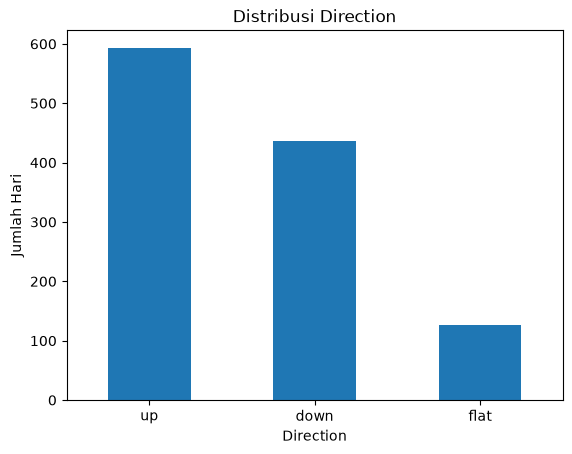

In [4]:
direction_counts = df["direction"].value_counts(dropna=False)

display(direction_counts.to_frame("count"))
display((direction_counts / len(df) * 100).round(2).to_frame("percentage"))

ax = direction_counts.plot(kind="bar")
ax.set_title("Distribusi Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Jumlah Hari")
plt.xticks(rotation=0)
plt.show()

## 3. Pergerakan JISDOR dan `log_return`

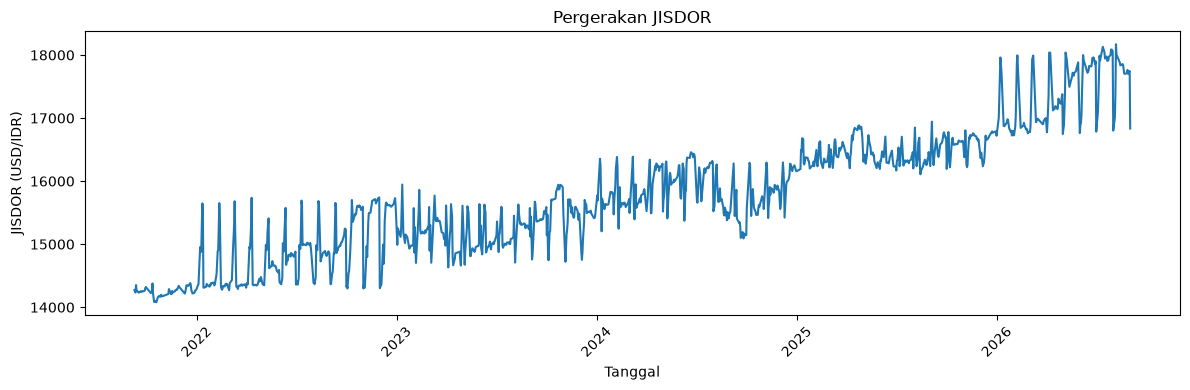

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["kurs"])
ax.set_title("Pergerakan JISDOR")
ax.set_xlabel("Tanggal")
ax.set_ylabel("JISDOR (USD/IDR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

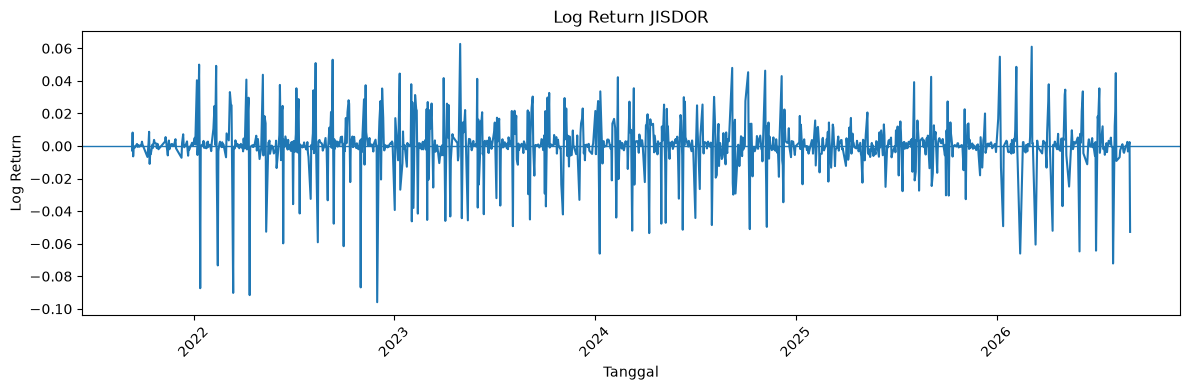

count    1155.000000
mean        0.000143
std         0.016616
min        -0.095933
25%        -0.002351
50%         0.000596
75%         0.004096
max         0.062721
Name: log_return, dtype: float64

In [6]:
log_return = df["log_return"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.loc[df["log_return"].notna(), "date"], log_return)
ax.axhline(0, linewidth=1)
ax.set_title("Log Return JISDOR")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Log Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(df["log_return"].describe())

## 4. Distribusi jumlah berita (`n_news`)

,n_news
count,1156.000000
mean,5.201557
std,7.185726
min,0.000000
25%,1.750000
50%,3.000000
75%,6.000000
max,88.000000


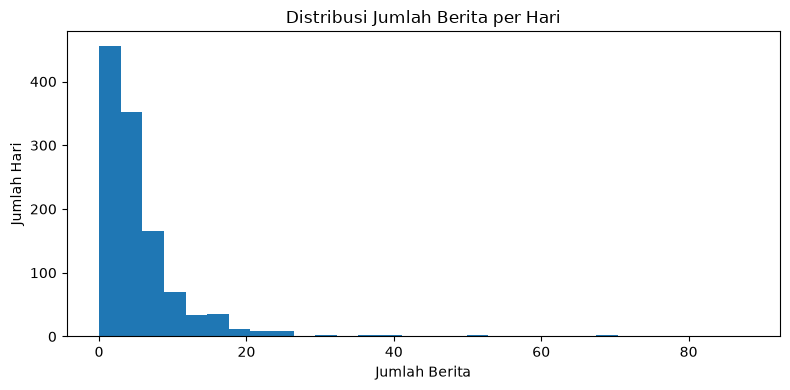

Hari tanpa berita: 126
Hari dengan berita: 1030


In [7]:
display(df["n_news"].describe().to_frame("n_news"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["n_news"].dropna(), bins=30)
ax.set_title("Distribusi Jumlah Berita per Hari")
ax.set_xlabel("Jumlah Berita")
ax.set_ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

print("Hari tanpa berita:", (df["n_news"] == 0).sum())
print("Hari dengan berita:", (df["n_news"] > 0).sum())

## 5. Distribusi `mean_relevance`

,mean_relevance
count,1030.000000
mean,7.268114
std,2.806954
min,2.000000
25%,5.250000
50%,7.000000
75%,9.000000
max,22.000000


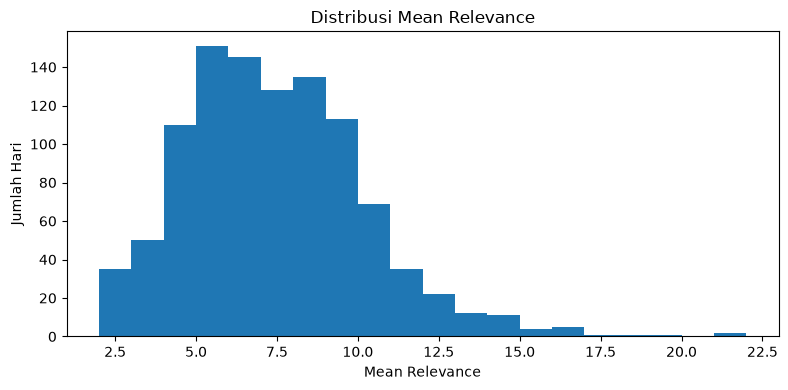

In [8]:
display(df["mean_relevance"].describe().to_frame("mean_relevance"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["mean_relevance"].dropna(), bins=20)
ax.set_title("Distribusi Mean Relevance")
ax.set_xlabel("Mean Relevance")
ax.set_ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

## 6. Hubungan fitur berita dengan arah kurs

In [9]:
# Ringkasan fitur berita berdasarkan direction
news_by_direction = (
    df.groupby("direction", dropna=False)[["n_news", "mean_relevance", "max_relevance", "mean_tokens", "pct_offhours"]]
      .agg(["count", "mean", "median"])
)

display(news_by_direction)

n_news                  mean_relevance                   \
           count      mean median          count      mean median   
direction                                                           
down         436  5.855505    3.0            398  7.231899    7.0   
flat         127  4.598425    3.0            109  7.593518    7.6   
up           593  4.849916    3.0            523  7.227855    7.0   

          max_relevance                   mean_tokens                      \
                  count       mean median       count        mean  median   
direction                                                                   
down                398  11.125628   11.0         398  567.889672  568.85   
flat                109  11.311927   11.0         109  570.519498  576.50   
up                  523  11.009560   11.0         523  564.965300  568.20   

          pct_offhours                   
                 count      mean median  
direction                                
down               398  0.827052    1.0  
flat               109  0.835107    1.0  
up                 523  0.816325    1.0

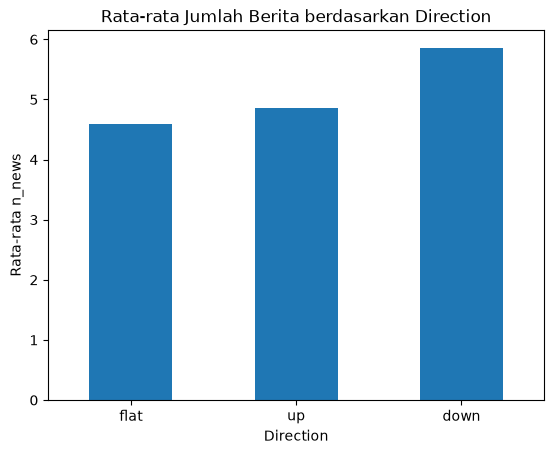

In [10]:
# Rata-rata jumlah berita per direction
mean_news = df.groupby("direction")["n_news"].mean().sort_values()

ax = mean_news.plot(kind="bar")
ax.set_title("Rata-rata Jumlah Berita berdasarkan Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Rata-rata n_news")
plt.xticks(rotation=0)
plt.show()

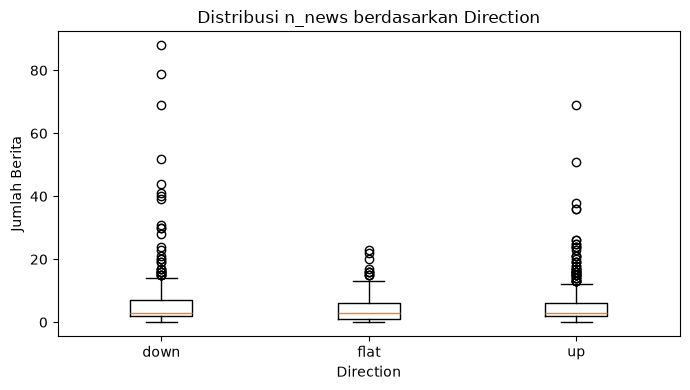

In [12]:
# Boxplot jumlah berita menurut direction
groups = []
labels = []

for label, group in df.groupby("direction"):
    groups.append(group["n_news"].dropna())
    labels.append(label)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(groups, tick_labels=labels)
ax.set_title("Distribusi n_news berdasarkan Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Jumlah Berita")
plt.tight_layout()
plt.show()

### Catatan interpretasi

Bagian ini hanya mengeksplorasi **asosiasi/pola awal**. Perbedaan jumlah berita atau sentiment/relevance antar-kelas **belum membuktikan hubungan kausal** dan belum berarti fitur tersebut akan meningkatkan performa model.

## 7. Missing value

In [13]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

display(missing.sort_values("missing_count", ascending=False))

,missing_count,missing_percentage
mean_relevance,126,10.90
max_relevance,126,10.90
mean_tokens,126,10.90
pct_offhours,126,10.90
text_norm_concat,126,10.90
prev_date,1,0.09
prev_kurs,1,0.09
gap_days,1,0.09
delta,1,0.09
log_return,1,0.09


## 8. Pemeriksaan tanggal dan potensi masalah temporal

In [14]:
# Cek duplikasi tanggal
print("Jumlah tanggal duplikat:", df["date"].duplicated().sum())

# Cek tanggal weekend
weekend_rows = df[df["date"].dt.dayofweek >= 5][["date", "kurs", "direction"]]
print("Jumlah row weekend:", len(weekend_rows))

if len(weekend_rows) > 0:
    display(weekend_rows.head(20))

# Cek urutan waktu
print("Tanggal minimum:", df["date"].min().date())
print("Tanggal maksimum:", df["date"].max().date())
print("Urutan tanggal sudah ascending:", df["date"].is_monotonic_increasing)

Jumlah tanggal duplikat: 0
Jumlah row weekend: 125


,date,kurs,direction
1,2021-09-11,14233.0,down
2,2021-09-12,14351.0,up
17,2021-10-09,14225.0,down
47,2021-12-11,14243.0,up
66,2022-01-08,14874.0,down
67,2022-01-09,14884.0,up
85,2022-02-06,14526.0,up
89,2022-02-12,15429.0,down
102,2022-03-06,14431.0,up
121,2022-04-02,14376.0,up


Tanggal minimum: 2021-09-09
Tanggal maksimum: 2026-09-01
Urutan tanggal sudah ascending: True


> **Penting:** bila pemeriksaan di atas menemukan tanggal non-business day pada data JISDOR, jangan langsung menghapusnya. Periksa kembali proses alignment/target terlebih dahulu karena kesalahan tanggal dapat memengaruhi eksperimen secara keseluruhan.

## 9. Temporal Train–Validation–Test Split

In [15]:
# Split kronologis 70% / 15% / 15%.
# Tidak menggunakan random split karena data memiliki urutan waktu.

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("TRAIN")
print(train["date"].min().date(), "→", train["date"].max().date(), "|", len(train), "rows")

print("\nVALIDATION")
print(validation["date"].min().date(), "→", validation["date"].max().date(), "|", len(validation), "rows")

print("\nTEST")
print(test["date"].min().date(), "→", test["date"].max().date(), "|", len(test), "rows")

TRAIN
2021-09-09 → 2025-02-10 | 809 rows

VALIDATION
2025-02-12 → 2025-10-29 | 173 rows

TEST
2025-10-30 → 2026-09-01 | 174 rows


In [16]:
# Simpan split untuk dipakai notebook/model berikutnya.
SPLIT_DIR = DATA_PATH.parent / "split"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train.to_csv(SPLIT_DIR / "train.csv", index=False)
validation.to_csv(SPLIT_DIR / "validation.csv", index=False)
test.to_csv(SPLIT_DIR / "test.csv", index=False)

print("Split disimpan di:", SPLIT_DIR.resolve())

Split disimpan di: /Users/aliyajumarna/Documents/Nyimut-NLP-26/data/processed/split


In [17]:
# Cek distribusi target per split
split_summary = pd.DataFrame({
    "train": train["direction"].value_counts(normalize=True),
    "validation": validation["direction"].value_counts(normalize=True),
    "test": test["direction"].value_counts(normalize=True),
}).fillna(0).round(3)

display(split_summary)

,train,validation,test
direction,,,
up,0.508,0.520,0.529
down,0.376,0.393,0.368
flat,0.116,0.087,0.103


## Output yang diharapkan

Setelah notebook dijalankan, kita harus punya:
- gambaran kualitas dan distribusi dataset,
- visualisasi JISDOR dan `log_return`,
- gambaran pola berita terhadap `direction`,
- daftar missing value,
- pengecekan tanggal/temporal alignment,
- `train.csv`, `validation.csv`, dan `test.csv`.

Notebook berikutnya baru digunakan untuk eksperimen model, dimulai dari **historical baseline** lalu dibandingkan dengan **TF-IDF/NLP baseline** dan **combined model**.